In [1]:
# Run target-specific analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
import ast
import sys
sys.path.append('/Users/wayne/Desktop/Cluster/ClusterHome/gitrepo/2024/OncoTRAIL/src')
from constants import target_dict_mapping

def load_and_prepare_dataframe(filepath: str, method_name: str, 
                                rename_cols: Optional[Dict[str, str]] = None,
                                transform_cols: Optional[Dict[str, callable]] = None) -> pd.DataFrame:
    """
    Load a CSV file and prepare it with method label and optional transformations.
    
    Parameters:
    -----------
    filepath : str
        Path to the CSV file
    method_name : str
        Name of the method to add as a column
    rename_cols : dict, optional
        Dictionary mapping old column names to new column names
    transform_cols : dict, optional
        Dictionary mapping column names to transformation functions
        
    Returns:
    --------
    pd.DataFrame
        Prepared dataframe with method column
    """
    df = pd.read_csv(filepath)
    df['method'] = method_name
    
    if rename_cols:
        df = df.rename(columns=rename_cols)
    
    if transform_cols:
        for col, transform_func in transform_cols.items():
            if col in df.columns:
                df[col] = df[col].apply(transform_func)
    
    return df


def load_all_method_dataframes(method_filepath_dict: Dict[str, str], 
                                split: str = "test") -> pd.DataFrame:
    """
    Load all method dataframes and concatenate them.
    
    Parameters:
    -----------
    method_filepath_dict : dict
        Dictionary mapping method names to file paths
        Example: {'prompting': '/path/to/file.csv', 'tabular': '/path/to/file2.csv'}
    split : str
        Name of the data split ('test', 'inference', etc.). Used to rename columns
        appropriately (e.g., 'test_ci' -> 'test_CI' or 'inference_ci' -> 'inference_CI')
        
    Returns:
    --------
    pd.DataFrame
        Concatenated dataframe with all methods
    """
    # Define method-specific transformations
    method_configs = {
        'prompting': {
            'rename_cols': {f'{split}_ci': f'{split}_CI'}
        },
        'finetune': {
            'transform_cols': {'target': lambda x: x.replace('_', '-')}
        }
    }
    
    # Load all dataframes
    dfs = []
    for method, filepath in method_filepath_dict.items():
        config = method_configs.get(method, {})
        
        df = load_and_prepare_dataframe(
            filepath=filepath,
            method_name=method,
            rename_cols=config.get('rename_cols'),
            transform_cols=config.get('transform_cols')
        )
        dfs.append(df)
    
    return pd.concat(dfs, ignore_index=True)


def target_category(target: str) -> str:
    """
    Categorize target based on naming patterns.
    
    Parameters:
    -----------
    target : str
        Target name
        
    Returns:
    --------
    str
        Target category ('lab', 'symptom', or 'clinic')
    """
    if 'grade2plus' in target:
        return 'lab'
    elif 'change' in target:
        return 'symptom'
    else:
        return 'clinic'

def prepare_specific_target_data(df_all: pd.DataFrame,
                                 target_mapping: Dict[str, str],
                                 split: str = "test",
                                 columns_to_keep: List[str] = None) -> pd.DataFrame:
    """
    Prepare dataframe for target-specific plotting with CI parsing.
    
    Parameters:
    -----------
    df_all : pd.DataFrame
        Concatenated dataframe with all methods
    target_mapping : dict
        Dictionary mapping original target names to display names
    split : str
        Name of the data split ('test', 'inference', etc.)
    columns_to_keep : list, optional
        List of columns to keep. If None, uses default columns based on split.
        
    Returns:
    --------
    pd.DataFrame
        Prepared dataframe with parsed CIs
    """
    auc_col = f'auc_{split}'
    ci_col = f'{split}_CI'
    
    if columns_to_keep is None:
        columns_to_keep = ['target', auc_col, 'method', 'target_type', ci_col]
    
    # Add target_type
    df_all['target_type'] = df_all['target'].apply(target_category)
    
    # Create copy and map target names
    df_specific = df_all.copy()
    df_specific['target'] = df_specific['target'].map(target_mapping)
    
    # Select columns
    df_specific = df_specific[columns_to_keep].copy()
    
    # Parse confidence intervals
    df_specific["ci_lower"] = df_specific[ci_col].apply(lambda x: ast.literal_eval(x)[0])
    df_specific["ci_upper"] = df_specific[ci_col].apply(lambda x: ast.literal_eval(x)[1])
    
    return df_specific


def plot_target_specific_auc(df_specific_ci: pd.DataFrame,
                             split: str = "test",
                             methods_order: List[str] = None,
                             target_type_order: List[str] = None,
                             palette: str = "Set2",
                             figsize: Tuple[int, int] = (10, 6),
                             title: str = None) -> Tuple[plt.Figure, plt.Axes]:
    """
    Create target-specific AUC plot with confidence intervals for each method.
    
    Parameters:
    -----------
    df_specific_ci : pd.DataFrame
        Dataframe with parsed CIs and target-specific data
    split : str
        Name of the data split ('test', 'inference', etc.)
    methods_order : list, optional
        Order of methods for plotting
    target_type_order : list, optional
        Order of target types for grouping
    palette : str, optional
        Color palette name
    figsize : tuple, optional
        Figure size (width, height)
    title : str, optional
        Plot title (if None, uses default based on split)
        
    Returns:
    --------
    Tuple[plt.Figure, plt.Axes]
        Figure and axes objects
    """
    if methods_order is None:
        # methods_order = ["tabular", "prompting", "nlp-tfidf", "nlp-count", "finetune"]
        methods_order = ["tabular", "bag of words", "finetune", "prompting"]

    # only retain methods_order that are in df_plot['method']
    methods_order = [m for m in methods_order if m in df_specific_ci['method'].unique()]

    if target_type_order is None:
        target_type_order = ["symptom", "lab", "clinic"]
    
    if title is None:
        title = f"Model AUC with 95% CI by Method and Target - {split.capitalize()}"
    
    auc_col = f'auc_{split}'
    
    # Apply ordering
    df_plot = df_specific_ci.copy()
    df_plot["target_type"] = pd.Categorical(
        df_plot["target_type"], 
        categories=target_type_order, 
        ordered=True
    )
    
    # Sort by target_type, target, and method
    df_plot = df_plot.sort_values(["target_type", "target", "method"])
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Color palette
    # colors = sns.color_palette(palette, len(methods_order))
    colors = ['#0072B2', '#009E73', '#CC79A7', '#E69F00']
    if len(methods_order) > len(colors):
        colors = sns.color_palette(palette, len(methods_order))

    # Vertical offset for methods
    method_offset = np.linspace(-0.2, 0.2, len(methods_order))
    
    # Assign numeric x positions for each target
    unique_targets = df_plot["target"].unique()
    x_positions = {target: i for i, target in enumerate(unique_targets)}
    
    # Draw confidence intervals and points
    for m_idx, method in enumerate(methods_order):
        subset = df_plot[df_plot["method"] == method]
        for _, row in subset.iterrows():
            x = x_positions[row["target"]] + method_offset[m_idx]
            
            # Vertical line for CI
            ax.vlines(
                x=x, 
                ymin=row["ci_lower"], 
                ymax=row["ci_upper"], 
                color=colors[m_idx], 
                alpha=0.6
            )
            
            # Point estimate
            ax.scatter(x, row[auc_col], color=colors[m_idx], s=60)
    
    # Set x-axis labels
    ax.set_xticks(list(x_positions.values()))
    ax.set_xticklabels(list(x_positions.keys()), rotation=45, ha="right")
    ax.tick_params(axis='x', which='both', length=0)
    
    # Labels and title
    ax.set_ylabel(f"AUC")
    # ax.set_xlabel("Target")
    ax.set_title(title, pad=10)
    
    # Reference line at 0.5 (random classifier)
    ax.axhline(0.5, color="gray", linestyle="--", lw=0.7, alpha=0.6)
    
    # Add group separators by target_type
    group_boundaries = (
        df_plot.groupby("target_type", observed=True)["target"]
        .unique()
        .apply(lambda x: x_positions[x[-1]] + 0.5)
    )
    for _, x_sep in group_boundaries[:-1].items():
        ax.axvline(x=x_sep, color="lightgray", linestyle=":", lw=0.8)
    
    # Legend
    # Legend location guide:
    # - 'upper left' -> upper left corner inside plot
    # - 'upper right' -> upper right corner inside plot
    # - 'lower left' -> lower left corner inside plot
    # - 'lower right' -> lower right corner inside plot
    # - 'center left' -> middle left inside plot
    # - 'center right' -> middle right inside plot
    # - 'upper center' -> top center inside plot
    # - 'lower center' -> bottom center inside plot
    # - 'center' -> dead center inside plot
    for m_idx, method in enumerate(methods_order):
        ax.scatter([], [], color=colors[m_idx], label=method, s=60)
    ax.legend(
        title="Method", 
        loc='upper left',  # Change this to move legend (see guide above)
        framealpha=0.9     # Semi-transparent background so you can see data underneath
    )
    
    # Styling
    sns.despine(ax=ax, left=True, bottom=True)
    ax.grid(False)
    
    plt.tight_layout()
    
    return fig, ax

def run_target_specific_analysis(method_filepath_dict: Dict[str, str],
                                 target_mapping: Dict[str, str],
                                 split: str = "test") -> Tuple[pd.DataFrame, plt.Figure, plt.Axes]:
    """
    Run target-specific analysis from data loading to plotting.
    
    Parameters:
    -----------
    method_filepath_dict : dict
        Dictionary mapping method names to file paths
    target_mapping : dict
        Dictionary mapping original target names to display names
    split : str
        Name of the data split ('test', 'inference', etc.)
        
    Returns:
    --------
    Tuple containing:
        - df_specific_ci: Dataframe with target-specific data and parsed CIs
        - fig: Figure object
        - ax: Axes object
    """
    # Load data
    df_all = load_all_method_dataframes(method_filepath_dict, split=split)
    
    # Prepare target-specific data
    df_specific_ci = prepare_specific_target_data(df_all, target_mapping, split=split)
    
    if split == 'test':
        title = "Temporal out-of-distribution 2016-2019"
    elif split == 'inference':
        title = "Temporal, institutional, case-mix out-of-distribution 2022-2024"

    # Create plot
    fig, ax = plot_target_specific_auc(df_specific_ci, split=split, title=title)
    
    return df_specific_ci, fig, ax

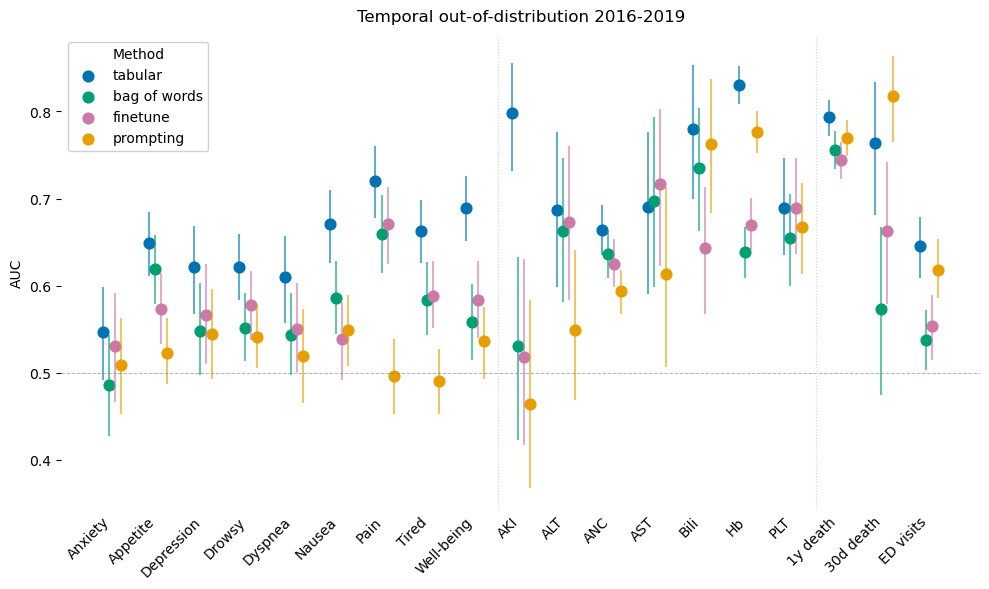

In [2]:
method_files_epr = {
    'prompting': '/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/results/aggregate/inference/prompting/prompting_results_train_test_inference.csv',
    'tabular': '/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/results/aggregate/train_test/tabular_nlp/best_result_summary_firstTreatmentOnly-medOnc-ConsultLetterClinic_deid_tabular_all_Temporal.csv',
    'bag of words': '/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/results/aggregate/train_test/tabular_nlp/best_result_summary_firstTreatmentOnly-medOnc-ConsultLetterClinic_deid_nlp-tfidf_all_Temporal.csv',
    # 'nlp-count': '/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/results/aggregate/train_test/tabular_nlp/best_result_summary_firstTreatmentOnly-medOnc-ConsultLetterClinic_deid_nlp-count_all_Temporal.csv',
    'finetune': '/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/results/aggregate/train_test/finetuning/best_finetune_results_for_comparison.csv'
}

split = "test"

df_target, fig_target, ax_target = run_target_specific_analysis(
    method_files_epr, target_dict_mapping, split
)

In [9]:
fig_target.savefig("tabular_vs_text_EPR.svg", bbox_inches="tight")

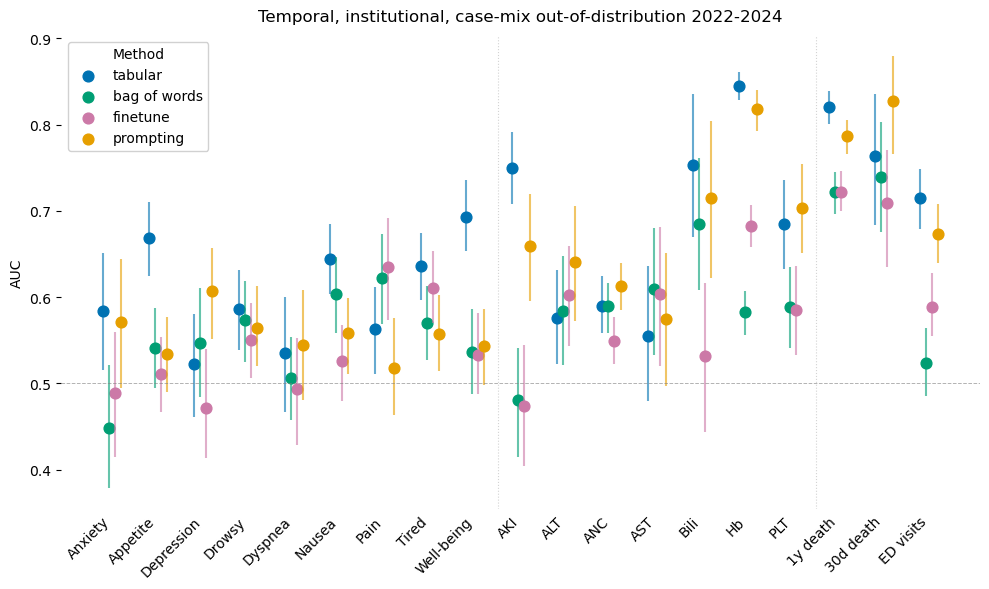

In [3]:
method_files_epic = {
    'prompting': '/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/results/aggregate/inference/prompting/prompting_results_train_test_inference.csv',
    'tabular': '/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/results/aggregate/inference/tabular_nlp/best_result_summary_firstTreatmentOnly-medOnc-ConsultLetterClinic_deid_tabular_all_Temporal.csv',
    'bag of words': '/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/results/aggregate/inference/tabular_nlp/best_result_summary_firstTreatmentOnly-medOnc-ConsultLetterClinic_deid_nlp-tfidf_all_Temporal.csv',
    # 'nlp-count': '/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/results/aggregate/inference/tabular_nlp/best_result_summary_firstTreatmentOnly-medOnc-ConsultLetterClinic_deid_nlp-count_all_Temporal.csv',
    'finetune': '/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/results/aggregate/inference/finetuning/best_finetune_results_for_comparison.csv'
}

split = "inference"

df_target, fig_target, ax_target = run_target_specific_analysis(
    method_files_epic, target_dict_mapping, split
)

In [11]:
fig_target.savefig("tabular_vs_text_EPIC.svg", bbox_inches="tight")

In [4]:
# load results from delong test
df_delong_epr = pd.read_csv('/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/results/aggregate/delong_comparison_test.csv')
df_delong_epr = df_delong_epr.loc[df_delong_epr['method'] != 'nlp-count']
df_delong_epic = pd.read_csv('/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/results/aggregate/delong_comparison_inference.csv')
df_delong_epic = df_delong_epic.loc[df_delong_epic['method'] != 'nlp-count']

In [5]:
n_comparisons = len(df_delong_epr) + len(df_delong_epic)
alpha = 0.05 / n_comparisons

In [6]:
epr_stat_significant = df_delong_epr.loc[df_delong_epr['p_value'] < alpha]
# loop over the methods and print the targets for each method
for method in epr_stat_significant['method'].unique():
    print(f"Method: {method}")
    targets = epr_stat_significant.loc[epr_stat_significant['method'] == method]['target'].unique()
    print(f"Targets: {targets}")
    print(len(targets))
    print()

Method: prompting
Targets: ['target_esas_appetite_3pt_change' 'target_esas_pain_3pt_change'
 'target_neutrophil_grade2plus' 'target_esas_tiredness_3pt_change'
 'target_esas_well_being_3pt_change' 'target_esas_nausea_3pt_change'
 'target_hemoglobin_grade2plus' 'target_AKI_grade2plus']
8

Method: nlp-tfidf
Targets: ['target_death_in_365d' 'target_ED_visit'
 'target_esas_well_being_3pt_change' 'target_hemoglobin_grade2plus'
 'target_AKI_grade2plus']
5

Method: finetune
Targets: ['target_death_in_365d' 'target_ED_visit'
 'target_esas_well_being_3pt_change' 'target_esas_nausea_3pt_change'
 'target_hemoglobin_grade2plus' 'target_AKI_grade2plus']
6



In [7]:
epic_stat_significant = df_delong_epic.loc[df_delong_epic['p_value'] < alpha]
# loop over the methods and print the targets for each method
for method in epic_stat_significant['method'].unique():
    print(f"Method: {method}")
    targets = epic_stat_significant.loc[epic_stat_significant['method'] == method]['target'].unique()
    print(f"Targets: {targets}")
    print(len(targets))
    print()

Method: prompting
Targets: ['target_esas_appetite_3pt_change' 'target_esas_well_being_3pt_change']
2

Method: nlp-tfidf
Targets: ['target_esas_appetite_3pt_change' 'target_death_in_365d'
 'target_ED_visit' 'target_esas_well_being_3pt_change'
 'target_hemoglobin_grade2plus' 'target_AKI_grade2plus']
6

Method: finetune
Targets: ['target_esas_appetite_3pt_change' 'target_death_in_365d'
 'target_bilirubin_grade2plus' 'target_ED_visit'
 'target_esas_well_being_3pt_change' 'target_esas_nausea_3pt_change'
 'target_hemoglobin_grade2plus' 'target_AKI_grade2plus']
8

